# Todo

In [1]:
import datetime as dt
import numpy as np
from numpy import datetime64 as dt
from numpy import timedelta64 as td
from pathlib import Path
import matplotlib as mpl
from matplotlib import pyplot as plt

import xarray as xr
import warnings
import pandas as pd
import geopandas as gpd

import scipy
from scipy.spatial import Voronoi, voronoi_plot_2d, ConvexHull, SphericalVoronoi
import cartopy.crs as ccrs
from cartopy.crs import Geodetic
import cartopy

warnings.simplefilter("ignore")

# Set Parameters

In [2]:
# Parameters
year = 2016
site = 0

isPapermill = False

In [3]:
suptitle_size = 20
title_size = 16
mapsize = (16, 8)
extent = (2.5, 27.5, 52, 62)
lonmid = np.mean(extent[:2])
latmid = np.mean(extent[2:])
map_projection = ccrs.Stereographic(
    central_longitude=lonmid, central_latitude=latmid,
    )
def basemap(ax):
    ax.set_extent(extent, ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [4]:
# Paths
folder_path = "/gxfs_work/geomar/smomw597/2025_copepods/output/"
trajectory_path = Path(folder_path, f"Trajectories/{year}/")
sample_Points_path = Path(folder_path, "SamplePoints/SamplePoints.shp")
voronoi_Polygons_path = Path(folder_path, "SamplePoints/VoronoiPolygons.shp")
out_path = Path(folder_path, f"VoronoiConnectivity/{year}/")

In [5]:
gdf_sample_points = gpd.read_file(sample_Points_path)
gdf_voronoi_polygons = gpd.read_file(voronoi_Polygons_path)

In [6]:
sample_name = gdf_sample_points.loc[site].SampleID
gdf_sample_points.SampleKind.loc[site] = "active"

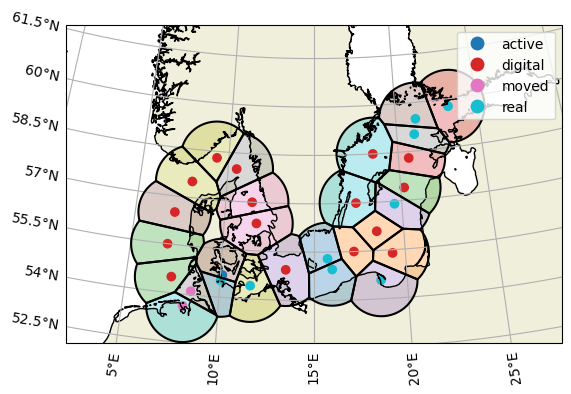

In [7]:
fig = plt.figure()
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_voronoi_polygons.plot(
    ax=ax_map,
    alpha=0.3, 
    column="PolygonID",
    )
gdf_voronoi_polygons.boundary.plot(ax=ax_map, color="k",)
gdf_sample_points.plot(ax=ax_map, column="SampleKind", legend=True, )
plt.show()

In [8]:
file = Path(
    trajectory_path, 
    f"PPmill_Nested_{year}0601-{year}1130_dt15min_{sample_name}_d0m-25m_N1000_seed123.zarr"
)
ds_trajectories = xr.open_zarr(file)
trajectories_age_mask = ds_trajectories.age_sec.chunk(chunks=[2000,2784]).compute() > 10*24*60*60
ds_trajectories = ds_trajectories.get(["lat","lon"]).where(trajectories_age_mask)

In [9]:
df_trajectories = ds_trajectories.to_dataframe().reset_index().dropna()
print(df_trajectories.size/1e9)

0.879664


In [10]:
gdf_traj = gpd.GeoDataFrame(
    # df.trajectory,
    geometry=gpd.points_from_xy(df_trajectories.lon, df_trajectories.lat, crs=ccrs.Geodetic())
    )

In [11]:
nrows_half = np.round(len(gdf_traj)/2).astype("int")

In [12]:
gdf_projected = gdf_traj[:nrows_half].to_crs(map_projection)
print("projected")
gdf_projected = gpd.sjoin(left_df=gdf_projected, right_df=gdf_voronoi_polygons, how="left", rsuffix="polygon")
print("joined")
gdf_projected_second = gdf_traj[nrows_half:].to_crs(map_projection)
print("projected")
gdf_projected_second = gpd.sjoin(left_df=gdf_projected_second, right_df=gdf_voronoi_polygons, how="left", rsuffix="polygon")
print("joined")
gdf_projected = pd.concat([gdf_projected, gdf_projected_second]).drop(columns=['index','index_polygon0', 'SampleKind'])

projected
joined
projected
joined


<Axes: xlabel='PolygonID'>

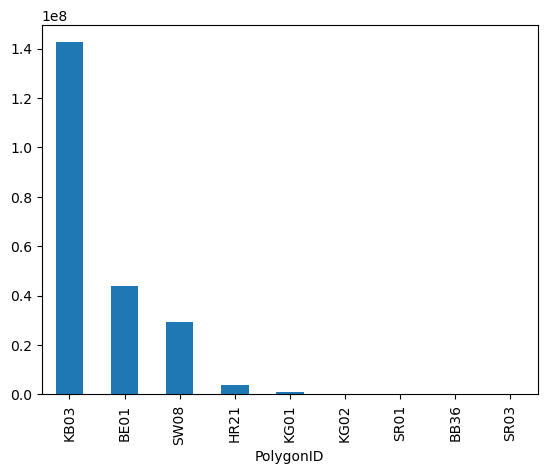

In [13]:
polygon_count = gdf_projected.PolygonID.value_counts()
polygon_count.plot(kind="bar")

In [14]:
connectivity_matrix = pd.DataFrame(
    np.zeros([len(gdf_sample_points.SampleID),len(gdf_sample_points.SampleID)]),
    index=gdf_sample_points.SampleID,
    columns=gdf_voronoi_polygons.PolygonID,
)
for polygon, count in polygon_count.items():
    connectivity_matrix.loc[sample_name].loc[polygon] = count
connectivity_matrix

PolygonID,KB03,SW08,BE01,GD01,IU07,LL17,FI01,SK02,WH02,KG01,...,EG01,EG02,SR03,WG01,WG02,BP03,BB23,BB36,GB96,HR21
SampleID,,,,,,,,,,,,,,,,,,,,,
KB03,142451753.0,29132812.0,43719821.0,0.0,0.0,0.0,0.0,0.0,0.0,831806.0,...,0.0,0.0,657.0,0.0,0.0,0.0,0.0,1758.0,0.0,3747636.0
SW08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BE01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GD01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IU07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
LL17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
FI01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SK02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
WH02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
connectivity_matrix.to_csv(
    Path(out_path, f"connectivitymatrix_voronoi_{sample_name}.csv")
)

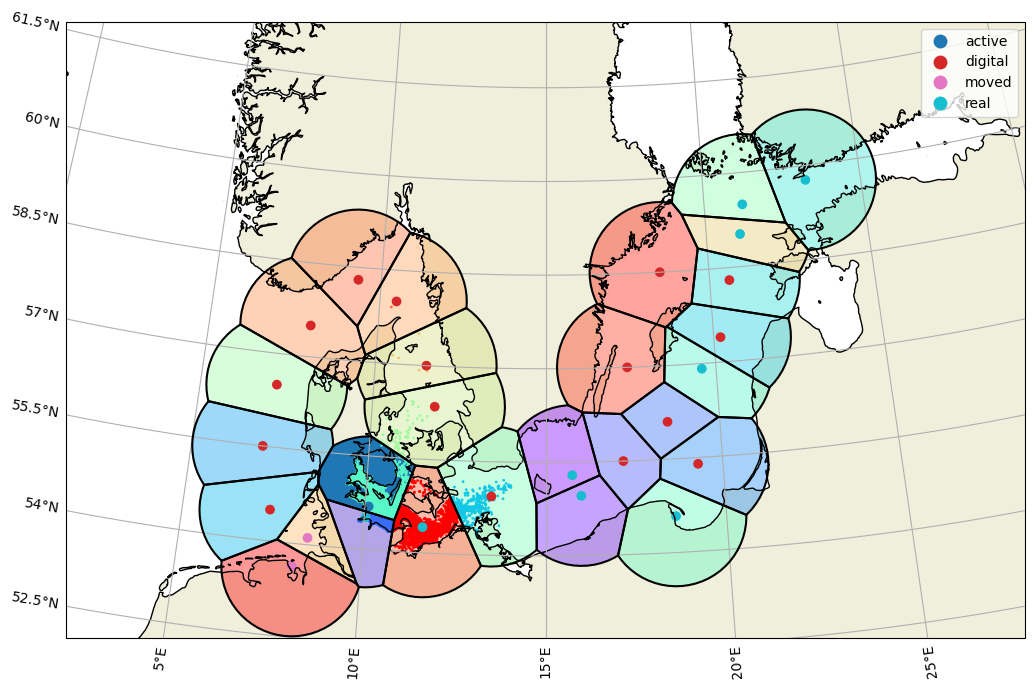

In [16]:
fig = plt.figure(figsize=mapsize)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_voronoi_polygons.to_crs(map_projection).plot(ax=ax_map,alpha=0.4, column="PolygonID", cmap="rainbow")
gdf_voronoi_polygons.where(gdf_voronoi_polygons.PolygonID==sample_name).to_crs(map_projection).plot(ax=ax_map, legend=True)
gdf_projected[::24*400].plot(ax=ax_map, column="PolygonID", cmap="rainbow", s=1)
gdf_voronoi_polygons.boundary.to_crs(map_projection).plot(ax=ax_map, color="k",)
gdf_sample_points.plot(ax=ax_map, column="SampleKind", legend=True)
plt.show()